# LightGBM model

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../../data/final_merged_dataset.parquet")
df = df.sort_values("datetime_hour").reset_index(drop=True)

In [3]:
print(df.dtypes.value_counts())
print(df.shape)

float64           448
int64               7
str                 4
bool                4
datetime64[us]      1
object              1
Name: count, dtype: int64
(853536, 465)


In [4]:
print("str cols:", df.select_dtypes(include='object').columns.tolist())
print("bool cols:", df.select_dtypes(include='bool').columns.tolist())
print("datetime cols:", df.select_dtypes(include='datetime64').columns.tolist())

str cols: ['city_name', 'day_datetime', 'day_sunrise', 'day_sunset', 'region_key']
bool cols: ['hour_conditions_simple_Clear', 'hour_conditions_simple_Cloudy', 'hour_conditions_simple_Rain', 'hour_conditions_simple_Snow']
datetime cols: ['datetime_hour']


C:\Users\Uw11\AppData\Local\Temp\ipykernel_11720\1106464062.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("str cols:", df.select_dtypes(include='object').columns.tolist())


In [5]:
y = df['alarm_active']
X = df.drop(columns=['datetime_hour', 'alarm_active', 'alarm_minutes_in_hour', 'region_key', 'day_datetime', 'day_sunrise', 'day_sunset', 'region_id'], errors="ignore")

In [6]:
X = X.select_dtypes(include=["number", "bool"]).copy()
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype("int8")

In [7]:
split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target balance train: {y_train.mean():.2%}")
print(f"Target balance test: {y_test.mean():.2%}")

Train: (682828, 456), Test: (170708, 456)
Target balance train: 19.02%
Target balance test: 30.83%


In [9]:
tscv = TimeSeriesSplit(n_splits=3)

In [10]:
param_grid = [
    {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "min_child_samples": 50},
    {"n_estimators": 500, "learning_rate": 0.03, "num_leaves": 63, "min_child_samples": 100},
    {"n_estimators": 600, "learning_rate": 0.03, "num_leaves": 63, "min_child_samples": 100, "reg_lambda": 2.0},
    {"n_estimators": 600, "learning_rate": 0.02, "num_leaves": 127, "min_child_samples": 100, "reg_lambda": 1.0},
]

best_score = -np.inf
best_params = None

for params in param_grid:
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(
            **params,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        model.fit(X_tr, y_tr)
        y_val_proba = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_val_proba)
        scores.append(score)

    mean_score = np.mean(scores)
    print(f"{params} -> ROC-AUC: {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best ROC-AUC: {best_score:.4f}")

{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 50} -> ROC-AUC: 0.8844
{'n_estimators': 500, 'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 100} -> ROC-AUC: 0.8849
{'n_estimators': 600, 'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 100, 'reg_lambda': 2.0} -> ROC-AUC: 0.8848
{'n_estimators': 600, 'learning_rate': 0.02, 'num_leaves': 127, 'min_child_samples': 100, 'reg_lambda': 1.0} -> ROC-AUC: 0.8852

Best params: {'n_estimators': 600, 'learning_rate': 0.02, 'num_leaves': 127, 'min_child_samples': 100, 'reg_lambda': 1.0}
Best ROC-AUC: 0.8852


In [11]:
lgbm_model = lgb.LGBMClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,127
,max_depth,-1
,learning_rate,0.02
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [12]:
y_pred = lgbm_model.predict(X_test)
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

In [13]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred, zero_division=0)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("=== FINAL TEST METRICS ===")
print("ROC-AUC :", round(roc_auc, 4))
print("PR-AUC  :", round(pr_auc, 4))
print("F1      :", round(f1, 4))
print("Precision:", round(precision, 4))
print("Recall  :", round(recall, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

=== FINAL TEST METRICS ===
ROC-AUC : 0.9418
PR-AUC  : 0.887
F1      : 0.7928
Precision: 0.7024
Recall  : 0.9099

Classification report:
              precision    recall  f1-score   support

           0     0.9538    0.8282    0.8865    118084
           1     0.7024    0.9099    0.7928     52624

    accuracy                         0.8534    170708
   macro avg     0.8281    0.8690    0.8397    170708
weighted avg     0.8763    0.8534    0.8576    170708



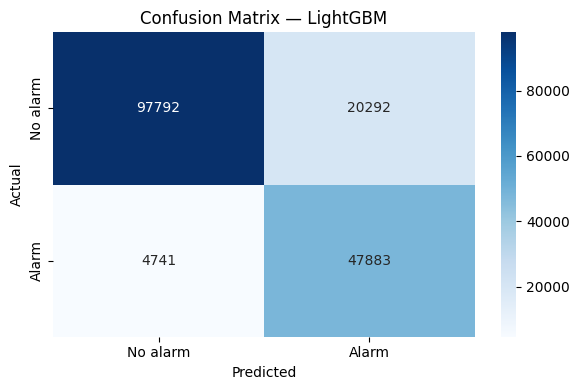

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No alarm", "Alarm"],
            yticklabels=["No alarm", "Alarm"])
plt.title("Confusion Matrix — LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [15]:
importance_df = pd.DataFrame({
    "feature": lgbm_model.booster_.feature_name(),
    "importance": lgbm_model.booster_.feature_importance(importance_type="gain")
})

top20 = (
    importance_df
    .sort_values("importance", ascending=False)
    .head(20)
)

top20_display = top20.copy()

top20_display["importance_%"] = (
    100 * top20_display["importance"] / top20_display["importance"].sum()
).round(2)

top20_display["importance"] = top20_display["importance"].map('{:,.0f}'.format)
top20_display["importance_%"] = top20_display["importance_%"].map('{:.2f}%'.format)

top20_display

,feature,importance,importance_%
432,alarm_lag_1,"7,207,734",71.61%
436,alarms_in_last_24h,"1,261,792",12.54%
440,neighbour_alarms,"456,405",4.53%
184,tg_topic_2,"192,024",1.91%
27,hour,"134,067",1.33%
439,total_active_alarms_lag1,"122,776",1.22%
441,hours_since_last_alarm,"122,712",1.22%
183,tg_topic_1,"87,211",0.87%
454,tg_intensity_ema_6h,"72,888",0.72%
185,tg_topic_3,"65,429",0.65%


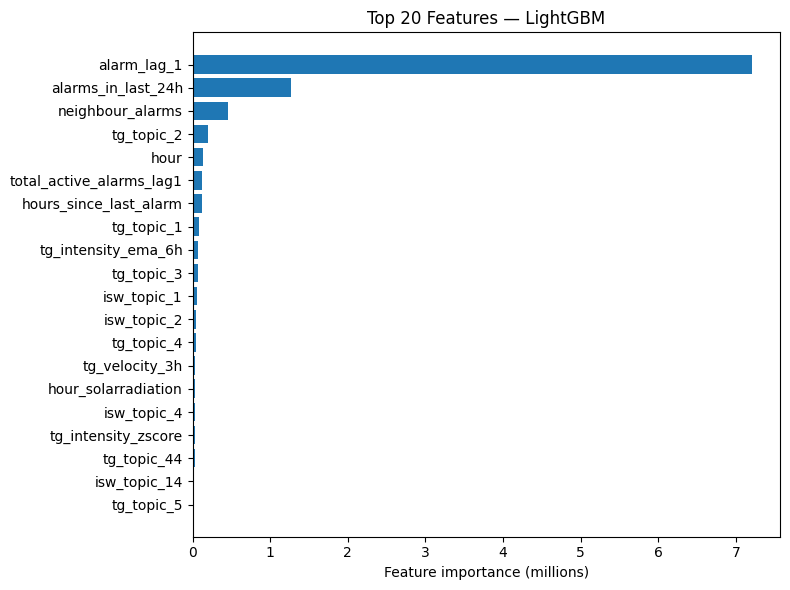

In [16]:
top20_sorted = top20.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))

top20_sorted["importance_k"] = top20_sorted["importance"] / 1000000

plt.barh(
    top20_sorted["feature"],
    top20_sorted["importance_k"]
)

plt.xlabel("Feature importance (millions)")
plt.title("Top 20 Features — LightGBM")

plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

In [17]:
#with open("lgbm_model.pkl", "wb") as f:
#    pickle.dump(lgbm_model, f)
#print("Model saved: lgbm_model.pkl")